<a href="https://colab.research.google.com/github/nakyungoh0314/past_tense_model_reimplementation/blob/main/Rumelhart_and_McClelland.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive

drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [2]:
# Below is a "magic" command, indicated by percent sign, which works even though it is not a Python function:
%cd /content/gdrive/MyDrive/PSYC711/common_verbs.csv

# Following command preceded by ! gets sent directly to the shell on the cloud
# machine, rather than to the Python interpreter
!ls

[Errno 20] Not a directory: '/content/gdrive/MyDrive/PSYC711/common_verbs.csv'
/content
gdrive	sample_data


In [3]:
import pandas as pd
import numpy as np
import csv
import re
from collections import defaultdict
from itertools import product
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv('/content/gdrive/MyDrive/PSYC711/common_verbs.csv')
print(df.columns)

Index(['Word', '3singular', 'Present Participle', 'Simple Past',
       'Past Participle'],
      dtype='object')


In [5]:
df = df[['Word', 'Simple Past']].copy()
df.columns = ['word', 'simple_past']
df['word'] = df['word'].str.strip().str.lower()
df['simple_past'] = df['simple_past'].str.strip().str.lower()

print(df.head())

    word simple_past
0     be         was
1   have         had
2     do         did
3  would         NaN
4   will       would


It shows that in the "simple_past", there is "would", which we do not have a past tense of "would". We need to remove it.

In [6]:
#Removing rows with missing or unstable values

bad_values = {'', '-', 'nan'}

df = df[
    (~df['word'].isin(bad_values)) &
    (~df['simple_past'].isin(bad_values))
].copy()

#Keep only rows that look like simple single-word verbs

df = df[
    df['word'].str.fullmatch(r"[a-z]+") &
    df['simple_past'].str.fullmatch(r"[a-z]+")
].copy()

print(df.head())

   word simple_past
0    be         was
1  have         had
2    do         did
4  will       would
5   can       could


In [7]:
#Remove duplicate rows

df = df.drop_duplicates()

#Reset index after cleaning

df = df.reset_index(drop = True)

print(df.head(10))

    word simple_past
0     be         was
1   have         had
2     do         did
3   will       would
4    can       could
5   know        knew
6    see         saw
7    may       might
8    get         got
9  think     thought


In [8]:
#Results for the data
print("Cleaned dataset shape:", df.shape)

print(df.head(10))

Cleaned dataset shape: (986, 2)
    word simple_past
0     be         was
1   have         had
2     do         did
3   will       would
4    can       could
5   know        knew
6    see         saw
7    may       might
8    get         got
9  think     thought


In [9]:
#Remove model like verbs that is not like past tense

exclude_verbs = {'would', 'should', 'could', 'must', 'may', 'might', 'shall', 'will', 'can'}

df = df[~df['word'].isin(exclude_verbs)].reset_index(drop = True)

In [10]:
#Set the 10 high freqeuncy verbs

high_freq_list = [
    ('come', 'came'),
    ('get', 'got'),
    ('give', 'gave'),
    ('look', 'looked'),
    ('take', 'took'),
    ('go', 'went'),
    ('have', 'had'),
    ('live', 'lived'),
    ('feel', 'felt'),
    ('make', 'made')
]

In [11]:
#Make the high frequency verbs to dataframe

high = pd.DataFrame(high_freq_list, columns = ['word', 'simple_past'])

print(high)

   word simple_past
0  come        came
1   get         got
2  give        gave
3  look      looked
4  take        took
5    go        went
6  have         had
7  live       lived
8  feel        felt
9  make        made


In [12]:
#Keep only rows that exactly match these pairs

high = df.merge(high, on = ['word', 'simple_past'], how = 'inner').copy()

high['freq_band'] = 'high'

print(high)

print('Number of high-frequency verbs:', len(high))

   word simple_past freq_band
0  have         had      high
1   get         got      high
2    go        went      high
3  make        made      high
4  take        took      high
5  come        came      high
6  give        gave      high
7  look      looked      high
8  feel        felt      high
9  live       lived      high
Number of high-frequency verbs: 10


In [13]:
#Check if all verb pairs match correctly

expected = set(high_freq_list)

found = set(map(tuple, high[['word', 'simple_past']].to_records(index = False)))

missing = expected - found

print('Missing high freqeuncy pairs:', missing)

Missing high freqeuncy pairs: set()


In [14]:
#Create the remainings except for the 10 high freqeuncy verbs

remaining = df.merge(high, on = ['word', 'simple_past'], how = 'left', indicator = True)

remaining = remaining[remaining['_merge'] == 'left_only'].drop(columns = ['_merge']).reset_index(drop = True)

In [15]:
#Medium Frequency Verbs

medium = remaining.iloc[50:460].copy()

medium['freq_band'] = 'medium'

#Low Frequency Verbs

low = remaining.iloc[700:786].copy()

low['freq_band'] = 'low'

final = pd.concat([high, medium, low], ignore_index = True)

print(final['freq_band'].value_counts())

print(final.head(15))

print(final.tail(15))

freq_band
medium    410
low        86
high       10
Name: count, dtype: int64
       word simple_past freq_band
0      have         had      high
1       get         got      high
2        go        went      high
3      make        made      high
4      take        took      high
5      come        came      high
6      give        gave      high
7      look      looked      high
8      feel        felt      high
9      live       lived      high
10  produce    produced    medium
11     stay      stayed    medium
12   appear    appeared    medium
13    write       wrote    medium
14     hold        held    medium
              word     simple_past freq_band
491       contract      contracted       low
492        machine        machined       low
493  differentiate  differentiated       low
494      advertise      advertised       low
495      reconcile      reconciled       low
496        project       projected       low
497     coordinate     coordinated       low
498           snap

Now we need to make sure whether the verbs are irregular or not.

In [16]:
# Making the formula of seeing whether it's an -ed, or another one.
# If it's an -ed -> regular
# If it's other -> irregular

def regular_verb(word, simple_past):
  if simple_past == word + "ed":
    return True
  if word.endswith("e") and simple_past == word + "d":
    return True
  if word.endswith("y") and len(word) > 1 and word[-2] not in "aeiou":
    if simple_past == word[:-1] + "ied":
      return True
  if(
      len(word) >= 3
      and word[-1] not in "aeiouyux"
      and word[-2] in "aeiou"
      and word[-3] not in "aeiou"
      and simple_past == word + word[-1] + "ed"
  ):
      return True
  return False

This checks if the word ends with a "ed" then its True, or if it has stopped, or tried, or something else, it shows as False

In [17]:
final['is_regular'] = final.apply(
    lambda row: regular_verb(row['word'], row['simple_past']),
    axis = 1)

final['verb_class'] = final['is_regular'].map({
    True: 'regular',
    False: 'irregular'
})

print(final[['word', 'simple_past', 'freq_band', 'verb_class']].head(20))
print(final['verb_class'].value_counts())
print(final.groupby(['freq_band', 'verb_class']).size())

       word simple_past freq_band verb_class
0      have         had      high  irregular
1       get         got      high  irregular
2        go        went      high  irregular
3      make        made      high  irregular
4      take        took      high  irregular
5      come        came      high  irregular
6      give        gave      high  irregular
7      look      looked      high    regular
8      feel        felt      high  irregular
9      live       lived      high    regular
10  produce    produced    medium    regular
11     stay      stayed    medium    regular
12   appear    appeared    medium    regular
13    write       wrote    medium  irregular
14     hold        held    medium  irregular
15   expect    expected    medium    regular
16   ensure     ensured    medium    regular
17  suppose    supposed    medium    regular
18     wish      wished    medium    regular
19    carry     carried    medium    regular
verb_class
regular      437
irregular     69
Name: coun

For the medium, we need to have 76 irregular, and 334 regular, and for the low, we need to have 14 irregular, and 72 regular like what the paper mentioned.

In [18]:
remaining["is_regular"] = remaining.apply(
    lambda row: regular_verb(row["word"], row["simple_past"]),
    axis = 1
)

remaining["verb_class"] = remaining["is_regular"].map({
    True: "regular",
    False: "irregular"
})

Inside the remaining dataset, I made sure what would the regular verb be and what would the irregular verb be.

In [19]:
# Creating the dataset that only has irregular and regular verbs

remaining_regular = remaining[remaining["verb_class"] == "regular"].copy()
remaining_irregular = remaining[remaining["verb_class"] == "irregular"].copy()

print(remaining_regular)
print(remaining_irregular)

         word simple_past freq_band  is_regular verb_class
7        want      wanted       NaN        True    regular
9        need      needed       NaN        True    regular
10       like       liked       NaN        True    regular
12        use        used       NaN        True    regular
16       help      helped       NaN        True    regular
..        ...         ...       ...         ...        ...
966    adhere     adhered       NaN        True    regular
968    summon    summoned       NaN        True    regular
969     pause      paused       NaN        True    regular
970     empty     emptied       NaN        True    regular
971  classify  classified       NaN        True    regular

[853 rows x 5 columns]
       word simple_past freq_band  is_regular verb_class
0        be         was       NaN       False  irregular
1        do         did       NaN       False  irregular
2      know        knew       NaN       False  irregular
3       see         saw       NaN       

In [20]:
# Now we need to assign them to the medium and low frequency verbs

medium_irregular = remaining_irregular.sample(n = 76, random_state = 1)

medium_regular = remaining_regular.sample(n = 334, random_state = 1)

print(medium_irregular)
print(medium_regular)

         word simple_past freq_band  is_regular verb_class
594      sink        sank       NaN       False  irregular
193      hurt        hurt       NaN       False  irregular
222      hang        hung       NaN       False  irregular
943     dwell       dwelt       NaN       False  irregular
381  withdraw    withdrew       NaN       False  irregular
..        ...         ...       ...         ...        ...
38       hear       heard       NaN       False  irregular
349     burst       burst       NaN       False  irregular
3         see         saw       NaN       False  irregular
738      tear        tore       NaN       False  irregular
82       send        sent       NaN       False  irregular

[76 rows x 5 columns]
          word  simple_past freq_band  is_regular verb_class
820     scream     screamed       NaN        True    regular
316   generate    generated       NaN        True    regular
570      range       ranged       NaN        True    regular
554  transform  transform

In [21]:
# Make sure words are not repeated for the low freqeuncy verbs

used_words = set(medium_irregular["word"]) | set(medium_regular["word"])

after_medium = remaining[
    ~remaining["word"].isin(used_words)
].copy()

# For the low frequency verb

low_irregular = after_medium[after_medium["verb_class"] == "irregular"].sample(n = 14, random_state = 1)

low_regular = after_medium[after_medium["verb_class"] == "regular"].sample(n = 72, random_state = 1)

print(low_irregular)
print(low_regular)

         word simple_past freq_band  is_regular verb_class
6         put         put       NaN       False  irregular
5         say        said       NaN       False  irregular
256  overcome    overcame       NaN       False  irregular
788     sweep       swept       NaN       False  irregular
73        win         won       NaN       False  irregular
416      wake        woke       NaN       False  irregular
223     throw       threw       NaN       False  irregular
581     light         lit       NaN       False  irregular
499      knit        knit       NaN       False  irregular
155    spread      spread       NaN       False  irregular
208     arise       arose       NaN       False  irregular
559      quit        quit       NaN       False  irregular
396     shoot        shot       NaN       False  irregular
568     steal       stole       NaN       False  irregular
           word  simple_past freq_band  is_regular verb_class
527   intervene   intervened       NaN        True   

In [22]:
# Combine and make it into one dataset for medium and low
# freqeuncy verbs

medium = pd.concat([medium_irregular, medium_regular], ignore_index = True)

medium['freq_band'] = 'medium'

low = pd.concat([low_irregular, low_regular], ignore_index = True)

low['freq_band'] = 'low'

final = pd.concat([high, medium, low], ignore_index = True)

print(final["freq_band"].value_counts())
print(final[['word', 'simple_past', 'freq_band', 'verb_class']].head(20))
print(final['verb_class'].value_counts())
print(final.groupby(['freq_band', 'verb_class']).size())


freq_band
medium    410
low        86
high       10
Name: count, dtype: int64
        word simple_past freq_band verb_class
0       have         had      high        NaN
1        get         got      high        NaN
2         go        went      high        NaN
3       make        made      high        NaN
4       take        took      high        NaN
5       come        came      high        NaN
6       give        gave      high        NaN
7       look      looked      high        NaN
8       feel        felt      high        NaN
9       live       lived      high        NaN
10      sink        sank    medium  irregular
11      hurt        hurt    medium  irregular
12      hang        hung    medium  irregular
13     dwell       dwelt    medium  irregular
14  withdraw    withdrew    medium  irregular
15      beat        beat    medium  irregular
16      sell        sold    medium  irregular
17      blow        blew    medium  irregular
18      shut        shut    medium  irregular
19

We need to train the 10-high frequency verbs and change it to the phonological root form, like how the model structure is.

In [23]:
# Getting the CMU dictionary

!pip install pronouncing

import pronouncing

def cmu(word):
  phones = pronouncing.phones_for_word(word)
  if len(phones) == 0:
    return None
  return phones[0]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 939.7/939.7 kB 14.9 MB/s eta 0:00:00


In [24]:
# I'm going to convert that CMU pronouncing to the
# pronounciation that came out from the past tense model
# based on the GPT

alphabet_to_rumelhart = {
    # stops
    "B": "b", "P": "p", "D": "d", "T": "t", "G": "g", "K": "k",

    # nasals
    "M": "m", "N": "n", "NG": "N",

    # fricatives
    "V": "v", "F": "f",
    "DH": "D", "TH": "T",
    "Z": "z", "S": "s",
    "ZH": "Z", "SH": "S",
    "HH": "h",

    # liquids / semivowels
    "L": "l", "R": "r", "W": "w", "Y": "j",

    # affricates: you will need to decide how to handle these
    "CH": "C",
    "JH": "J",

    # vowels (approximate)
    "IY": "E",   # beet
    "IH": "i",   # bit
    "EY": "A",   # bait
    "EH": "e",   # bet
    "AE": "a",   # bat
    "AA": "o",   # father/hot-ish category
    "AH": "^",   # but / schwa-like
    "AO": "*",   # saw
    "OW": "O",   # boat
    "UH": "u",   # book
    "UW": "U",   # boot
    "AW": "W",   # cow
    "AY": "I",   # bite
    "OY": "Y",   # toy
    "ER": "R",   # we need to add this part even though Rumelhard model table didn't have this cuz we have different dataset
}

In [25]:
# Then, we need to change the AH1 or EY1 to AH or EY
# based on GPT

import re

def rumelhart(cmu_string):
  if cmu_string is None:
    return None
  phones = cmu_string.split()
  rumelhart_phones = []
  for phone in phones:
    phone_clean = re.sub(f"\d", "", phone)
    if phone_clean in alphabet_to_rumelhart:
      rumelhart_phones.append(alphabet_to_rumelhart[phone_clean])
    else:
      raise ValueError(f"Missing mapping for alphabet phone: {phone_clean}")
  return "".join(rumelhart_phones)

<>:12: SyntaxWarning: invalid escape sequence '\d'
<>:12: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_391/2459799154.py:12: SyntaxWarning: invalid escape sequence '\d'
  phone_clean = re.sub(f"\d", "", phone)


In [26]:
# Apply it to 10-high frequency words

high["root_cmu"] = high["word"].apply(cmu)

high["past_cmu"] = high["simple_past"].apply(cmu)

high["root_rum"] = high["root_cmu"].apply(rumelhart)

high["past_rum"] = high["past_cmu"].apply(rumelhart)

print(high)

   word simple_past freq_band  root_cmu   past_cmu root_rum past_rum
0  have         had      high  HH AE1 V   HH AE1 D      hav      had
1   get         got      high   G EH1 T    G AA1 T      get      got
2    go        went      high     G OW1  W EH1 N T       gO     went
3  make        made      high   M EY1 K    M EY1 D      mAk      mAd
4  take        took      high   T EY1 K    T UH1 K      tAk      tuk
5  come        came      high   K AH1 M    K EY1 M      k^m      kAm
6  give        gave      high   G IH1 V    G EY1 V      giv      gAv
7  look      looked      high   L UH1 K  L UH1 K T      luk     lukt
8  feel        felt      high   F IY1 L  F EH1 L T      fEl     felt
9  live       lived      high   L AY1 V  L IH1 V D      lIv     livd


I need to break the 10 high frequency verbs to wickelphone representation before breaking it down to the wickelfeature representation of the root form

In [27]:
def wickelphones(phone_string):
  if phone_string is None:
    return None
  bounded = "#" + phone_string + "#"
  wickel_phones = [
      bounded[i: i + 3]
      for i in range(len(bounded) - 2)
  ]
  return wickel_phones

In [28]:
# Apply to the root and past tense form

high["root_wickel"] = high["root_rum"].apply(wickelphones)

high["past_wickel"] = high["past_rum"].apply(wickelphones)

print(high)

   word simple_past freq_band  root_cmu   past_cmu root_rum past_rum  \
0  have         had      high  HH AE1 V   HH AE1 D      hav      had   
1   get         got      high   G EH1 T    G AA1 T      get      got   
2    go        went      high     G OW1  W EH1 N T       gO     went   
3  make        made      high   M EY1 K    M EY1 D      mAk      mAd   
4  take        took      high   T EY1 K    T UH1 K      tAk      tuk   
5  come        came      high   K AH1 M    K EY1 M      k^m      kAm   
6  give        gave      high   G IH1 V    G EY1 V      giv      gAv   
7  look      looked      high   L UH1 K  L UH1 K T      luk     lukt   
8  feel        felt      high   F IY1 L  F EH1 L T      fEl     felt   
9  live       lived      high   L AY1 V  L IH1 V D      lIv     livd   

       root_wickel           past_wickel  
0  [#ha, hav, av#]       [#ha, had, ad#]  
1  [#ge, get, et#]       [#go, got, ot#]  
2       [#gO, gO#]  [#we, wen, ent, nt#]  
3  [#mA, mAk, Ak#]       [#mA, mAd,

I need to break down those wickelphones into wickelfeatures. Below is the code that was in Table 5 of the categorization of phonemes on four simple dimensions.

In [29]:
# This basically stores for every phoneme symbol, stores its
# 4 feature values. (Followed the Table 5 categorizing)

phoneme_features = {
    #we treat boundaries as part of the Wickelphone representation
    "#": {"major_type" : "boundary", "subtype" : "boundary", "place" : "boundary", "voice_length" : "boundary"},
    #Interrupted consonants : stop
    "b" : {"major_type" : "interrupted", "subtype" : "stop", "place" : "front", "voice_length": "voiced"},
    "p" : {"major_type" : "interrupted", "subtype" : "stop", "place" : "front", "voice_length": "voiceless"},
    "d" : {"major_type" : "interrupted", "subtype" : "stop", "place" : "middle", "voice_length": "voiced"},
    "t" : {"major_type" : "interrupted", "subtype" : "stop", "place" : "middle", "voice_length": "voiceless"},
    "g" : {"major_type" : "interrupted", "subtype" : "stop", "place" : "back", "voice_length": "voiced"},
    "k" : {"major_type" : "interrupted", "subtype" : "stop", "place" : "back", "voice_length": "voiceless"},

    #Interrupted consonants : Nasal
    "m" : {"major_type" : "interrupted", "subtype" : "nasal", "place" : "front", "voice_length": "voiced"},
    "n" : {"major_type" : "interrupted", "subtype" : "nasal", "place" : "middle", "voice_length": "voiced"},
    "N" : {"major_type" : "interrupted", "subtype" : "nasal", "place" : "back", "voice_length" : "voiced"},

    #Continuous consonants : fricatives
    "v" : {"major_type" : "continuous", "subtype" : "fricatives", "place" : "front", "voice_length" : "voiced"},
    "D" : {"major_type" : "continuous", "subtype" : "fricatives", "place" : "front", "voice_length" : "voiced"},
    "f" : {"major_type" : "continuous", "subtype" : "fricatives", "place" : "middle", "voice_length" : "voiceless"},
    "T" : {"major_type" : "continuous", "subtype" : "fricatives", "place" : "middle", "voice_length" : "voiceless"},
    "z" : {"major_type" : "continuous", "subtype" : "fricatives", "place" : "middle", "voice_length" : "voiced"},
    "s" : {"major_type" : "continuous", "subtype" : "fricatives", "place" : "middle", "voice_length" : "voiceless"},
    "Z" : {"major_type" : "continuous", "subtype" : "fricatives", "place" : "back", "voice_length" : "voiced"},
    "j" : {"major_type" : "continuous", "subtype" : "fricatives", "place" : "back", "voice_length" : "voiced"},
    "S" : {"major_type" : "continuous", "subtype" : "fricatives", "place" : "back", "voice_length" : "voiceless"},
    "C" : {"major_type" : "continuous", "subtype" : "fricatives", "place" : "back", "voice_length" : "voiceless"},
    "J" : {"major_type" : "continuous", "subtype" : "fricatives", "place" : "middle", "voice_length" : "voiced"},

    #Continuous consonants : liquid/semivowels
    "w" : {"major_type" : "continuous", "subtype" : "liqsv", "place" : "front", "voice_length" : "voiced"},
    "l" : {"major_type" : "continuous", "subtype" : "liqsv", "place" : "front", "voice_length" : "voiecd"},
    "r" : {"major_type" : "continuous", "subtype" : "liqsv", "place" : "middle", "voice_length" : "voiced"},
    "y" : {"major_type" : "continuous", "subtype" : "liqsv", "place" : "back", "voice_length" : "voiced"},
    "h" : {"major_type" : "continuous", "subtype" : "liqsv", "place" : "back", "voice_length" : "voiceless"},
    "R" : {"major_type" : "continuous", "subtype" : "liqsv", "place" : "middle", "voice_length" : "voiced"},

    #Vowel consonants : High
    "E" : {"major_type" : "vowel", "subtype" : "high", "place" : "front", "voice_length" : "long"},
    "i" : {"major_type" : "vowel", "subtype" : "high", "place" : "front", "voice_length" : "short"},
    "O" : {"major_type" : "vowel", "subtype" : "high", "place" : "middle", "voice_length" : "long"},
    "^" : {"major_type" : "vowel", "subtype" : "high", "place" : "middle", "voice_length" : "short"},
    "U" : {"major_type" : "vowel", "subtype" : "high", "place" : "back", "voice_length" : "long"},
    "u" : {"major_type" : "vowel", "subtype" : "high", "place" : "back", "voice_length" : "short"},

    #Vowel consonants : Low
    "A" : {"major_type" : "vowel", "subtype" : "low", "place" : "front", "voice_length" : "long"},
    "e" : {"major_type" : "vowel", "subtype" : "low", "place" : "front", "voice_length" : "short"},
    "I" : {"major_type" : "vowel", "subtype" : "low", "place" : "middle", "voice_length" : "long"},
    "a" : {"major_type" : "vowel", "subtype" : "low", "place" : "middle", "voice_length" : "short"},
    "∂" : {"major_type" : "vowel", "subtype" : "low", "place" : "middle", "voice_length" : "short"},
    "W" : {"major_type" : "vowel", "subtype" : "low", "place" : "back", "voice_length" : "long"},
    "*" : {"major_type" : "vowel", "subtype" : "low", "place" : "bakc", "voice_length" : "short"},
    "o" : {"major_type" : "vowel", "subtype" : "low", "place" : "back", "voice_length" : "short"},
    "Y" : {"major_type" : "vowel", "subtype" : "low", "place" : "back", "voice_length" : "long"}}

In [30]:
def symbol(phoneme):
  if phoneme not in phoneme_features:
    raise ValueError(f"Missing phoneme symbol: {phoneme}")
  return list(phoneme_features[phoneme].values())

print(symbol("k"))

['interrupted', 'stop', 'back', 'voiceless']


In [31]:
# Convert on wickelphone to wickelfeatures

def wickelfeature(wickelphone):
  left, middle, right = wickelphone
  left_features = symbol(left)
  middle_features = symbol(middle)
  right_features = symbol(right)
  wickelfeatures = set()
  for left_feature in left_features:
    for middle_feature in middle_features:
      for right_feature in right_features:
        wickelfeatures.add((left_feature, middle_feature, right_feature))
  return wickelfeatures

test = wickelfeature("kAm")

for f in test:
  print(f)

('back', 'low', 'interrupted')
('interrupted', 'low', 'voiced')
('voiceless', 'vowel', 'nasal')
('voiceless', 'vowel', 'front')
('interrupted', 'vowel', 'nasal')
('stop', 'vowel', 'voiced')
('stop', 'long', 'voiced')
('back', 'front', 'nasal')
('interrupted', 'vowel', 'front')
('back', 'front', 'front')
('interrupted', 'long', 'nasal')
('back', 'long', 'interrupted')
('back', 'vowel', 'interrupted')
('voiceless', 'long', 'voiced')
('interrupted', 'long', 'front')
('stop', 'front', 'interrupted')
('voiceless', 'front', 'interrupted')
('voiceless', 'vowel', 'voiced')
('back', 'front', 'voiced')
('back', 'low', 'nasal')
('back', 'low', 'front')
('interrupted', 'long', 'voiced')
('interrupted', 'vowel', 'voiced')
('stop', 'low', 'interrupted')
('interrupted', 'front', 'interrupted')
('back', 'vowel', 'front')
('back', 'long', 'nasal')
('back', 'vowel', 'nasal')
('stop', 'front', 'nasal')
('back', 'low', 'voiced')
('back', 'long', 'front')
('voiceless', 'front', 'nasal')
('stop', 'front', '

Now, we need to convert that to all the words in high frequency.

In [32]:
def wickelfeatures(word):
  wickelphones_word = wickelphones(word)
  all_features = set()
  for wickelphone in wickelphones_word:
    all_features.update(wickelfeature(wickelphone))
  return all_features

In [33]:
# Apply it into high frequency

high["root_features"] = high["root_rum"].apply(wickelfeatures)

high["past_features"] = high["past_rum"].apply(wickelfeatures)

print(high)

   word simple_past freq_band  root_cmu   past_cmu root_rum past_rum  \
0  have         had      high  HH AE1 V   HH AE1 D      hav      had   
1   get         got      high   G EH1 T    G AA1 T      get      got   
2    go        went      high     G OW1  W EH1 N T       gO     went   
3  make        made      high   M EY1 K    M EY1 D      mAk      mAd   
4  take        took      high   T EY1 K    T UH1 K      tAk      tuk   
5  come        came      high   K AH1 M    K EY1 M      k^m      kAm   
6  give        gave      high   G IH1 V    G EY1 V      giv      gAv   
7  look      looked      high   L UH1 K  L UH1 K T      luk     lukt   
8  feel        felt      high   F IY1 L  F EH1 L T      fEl     felt   
9  live       lived      high   L AY1 V  L IH1 V D      lIv     livd   

       root_wickel           past_wickel  \
0  [#ha, hav, av#]       [#ha, had, ad#]   
1  [#ge, get, et#]       [#go, got, ot#]   
2       [#gO, gO#]  [#we, wen, ent, nt#]   
3  [#mA, mAk, Ak#]       [#mA, 

Now we need to convert them to the binary vector to put them as the input and output.

In [34]:
# This function builds the FULL Wickelfeature inventory across the
# dataset.

# That inventory defines the dimensions of the model's input/output
# vectors

def build_wickel(words):
  inventory = set()
  for word in words:
    inventory.update(wickelfeatures(word))
  return sorted(inventory)

In [35]:
# Create this to binary vectors

def vector(wickelfeatures, inventory):
  feature_set = set(wickelfeatures)
  return[1 if feature in feature_set else 0 for feature in inventory]

inventory = build_wickel(["kAm"])

features_kAm = wickelfeatures("kAm")

vector_kAm = vector(features_kAm, inventory)

print("Inventory size:", len(inventory))
print("Number of active features:", sum(vector_kAm))
print("Vector:", vector_kAm)

Inventory size: 96
Number of active features: 96
Vector: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [36]:
def wickelfeature_vector(word, inventory):
  features = wickelfeatures(word)
  return vector(features, inventory)

In [37]:
# Apply it to high frequency verbs

all_forms = list(high["root_rum"]) + list(high["past_rum"])

inventory = build_wickel(all_forms)

high["root_vector"] = high["root_rum"].apply(
    lambda x: wickelfeature_vector(x, inventory))

high["past_vector"] = high["past_rum"].apply(
    lambda x: wickelfeature_vector(x, inventory))

print(high)

   word simple_past freq_band  root_cmu   past_cmu root_rum past_rum  \
0  have         had      high  HH AE1 V   HH AE1 D      hav      had   
1   get         got      high   G EH1 T    G AA1 T      get      got   
2    go        went      high     G OW1  W EH1 N T       gO     went   
3  make        made      high   M EY1 K    M EY1 D      mAk      mAd   
4  take        took      high   T EY1 K    T UH1 K      tAk      tuk   
5  come        came      high   K AH1 M    K EY1 M      k^m      kAm   
6  give        gave      high   G IH1 V    G EY1 V      giv      gAv   
7  look      looked      high   L UH1 K  L UH1 K T      luk     lukt   
8  feel        felt      high   F IY1 L  F EH1 L T      fEl     felt   
9  live       lived      high   L AY1 V  L IH1 V D      lIv     livd   

       root_wickel           past_wickel  \
0  [#ha, hav, av#]       [#ha, had, ad#]   
1  [#ge, get, et#]       [#go, got, ot#]   
2       [#gO, gO#]  [#we, wen, ent, nt#]   
3  [#mA, mAk, Ak#]       [#mA, 

In [38]:
# Check active feature counts for each vector

high["root_active_count"] = high["root_vector"].apply(sum)

high["past_active_count"] = high["past_vector"].apply(sum)

print(
    high[
        ["word", "simple_past", "root_rum", "past_rum", "root_active_count", "past_active_count"]
    ]
)

   word simple_past root_rum past_rum  root_active_count  past_active_count
0  have         had      hav      had                 96                 96
1   get         got      get      got                 96                 96
2    go        went       gO     went                 32                160
3  make        made      mAk      mAd                 96                 96
4  take        took      tAk      tuk                 96                 96
5  come        came      k^m      kAm                 96                 96
6  give        gave      giv      gAv                 96                 96
7  look      looked      luk     lukt                 96                160
8  feel        felt      fEl     felt                 96                160
9  live       lived      lIv     livd                 96                159


Now we need to do the pattern associator part where I plan to do the activation function, which is the logistic/probablistic activation function for output units.

In [39]:
# Put the root and past tense forms into x and y

x_high = np.array(high["root_vector"].tolist())

y_high = np.array(high["past_vector"].tolist())

print(x_high.shape)
print(y_high.shape)

(10, 1098)
(10, 1098)


In [40]:
# Number of output and input units

n_input = x_high.shape[1]

n_output = y_high.shape[1]

print(n_input)
print(n_output)

1098
1098


In [41]:
# Weights are initialized as zeros

w = np.zeros((n_input, n_output))

print(w)

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [42]:
# Theta is also started as zero

theta = np.zeros(n_output)

print(theta)

[0. 0. 0. ... 0. 0. 0.]


In [43]:
# Logistic/probablistic activation function

def logistic(net_input, theta, T = 200):
  return 1 / (1 + np.exp(-(net_input - theta) / T))

In [44]:
# Prediction function

def predict(x, w, theta, T = 200, stochastic = True):
  net_input = x @ w
  probabilities = logistic(net_input, theta, T = T)
  if stochastic:
    output_vector = (np.random.random(size = probabilities.shape) < probabilities).astype(int)
  else:
    output_vector = (probabilities > 0.5).astype(int)
  return output_vector, probabilities

x = x_high[0]

pred, probs = predict(x, w, theta, T = 200, stochastic = True)

We need to make the model learn the rule with using the classic perceptron convergence procedure.

In [45]:
# Create the learning rule formula

def perceptron(x, target, output, w, theta, eta = 1):
  error = target - output
  w += eta * np.outer(x, error)
  theta -= eta * error
  return w, theta

In [46]:
# Used GPT to test the example
# Pick one training example

x = x_high[0]

target = y_high[0]

# Make prediction before learning

output, probs = predict(x, w, theta, T = 200, stochastic = True)

print("Before update")
print("Predicted active units:", output.sum())
print("Target active units:", target.sum())
print("Number of wrong units:", np.sum(output != target))

Before update
Predicted active units: 552
Target active units: 96
Number of wrong units: 546


In [47]:
# Apply perceptron update

w, theta = perceptron(x, target, output, w, theta, eta = 1)

# Make prediction again after one update

output_after, probs_after = predict(x, w, theta, T = 200, stochastic = True)

print("\nAfter one update")
print("Predicted active units:", output_after.sum())
print("Target active units:", target.sum())
print("Number of wrong units:", np.sum(output_after != target))


After one update
Predicted active units: 500
Target active units: 96
Number of wrong units: 502


Because it needs to keep learning, we need to train it repeatedly.

In [48]:
# Train for 10 cycles

errors = []

for epoch in range(10):
  total_wrong = 0
  for x, target in zip(x_high, y_high):
    output_vector, probs = predict(x, w, theta, T = 200, stochastic = True)
    wrong = np.sum(output_vector != target)
    total_wrong += wrong

    w, theta = perceptron(x, target, output_vector, w, theta, eta = 1)
  errors.append(total_wrong)
  print(f"Epoch {epoch + 1}: wrong output units = {total_wrong}")

Epoch 1: wrong output units = 5236
Epoch 2: wrong output units = 4351
Epoch 3: wrong output units = 3727
Epoch 4: wrong output units = 3312
Epoch 5: wrong output units = 2863
Epoch 6: wrong output units = 2538
Epoch 7: wrong output units = 2291
Epoch 8: wrong output units = 2103
Epoch 9: wrong output units = 2012
Epoch 10: wrong output units = 1813


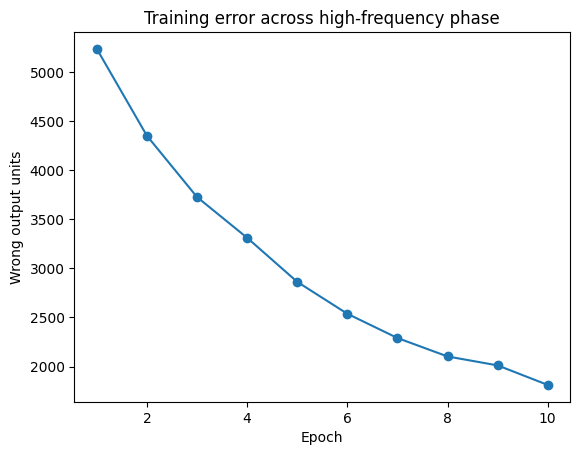

In [49]:
# Visualization on looking at training errors

plt.plot(range(1, len(errors) + 1), errors, marker = "o")
plt.xlabel("Epoch")
plt.ylabel("Wrong output units")
plt.title("Training error across high-frequency phase")
plt.show()

We could see that the training error does go down even though there are some parts that suddenly increase and decrease.

Now we should add the 410 medium frequency verbs as the same way we did it to the 10 frequency verbs.

In [50]:
# Convert medium frequency to Rumelhart and phonological
# forms

medium["root_cmu"] = medium["word"].apply(cmu)

medium["past_cmu"] = medium["simple_past"].apply(cmu)

medium["root_rum"] = medium["root_cmu"].apply(rumelhart)

medium["past_rum"] = medium["past_cmu"].apply(rumelhart)

print(medium)

         word simple_past freq_band  is_regular verb_class           root_cmu  \
0        sink        sank    medium       False  irregular         S IH1 NG K   
1        hurt        hurt    medium       False  irregular           HH ER1 T   
2        hang        hung    medium       False  irregular          HH AE1 NG   
3       dwell       dwelt    medium       False  irregular          D W EH1 L   
4    withdraw    withdrew    medium       False  irregular   W IH0 DH D R AO1   
..        ...         ...       ...         ...        ...                ...   
405    result    resulted    medium        True    regular    R IH0 Z AH1 L T   
406   explore    explored    medium        True    regular  IH0 K S P L AO1 R   
407    regain    regained    medium        True    regular      R IH0 G EY1 N   
408   scratch   scratched    medium        True    regular       S K R AE1 CH   
409     guard     guarded    medium        True    regular          G AA1 R D   

                  past_cmu 

Because the cmu dictionary did not have some pronounciations for certain verbs, we just dropped them. Total 4 was dropped in the medium, so the medium frequency has 406.

In [51]:
# Make the column for regularity in high frequency verbs

medium = medium.dropna(subset = ["past_cmu", "past_rum"]).copy()

high["is_regular"] = high.apply(
    lambda row: regular_verb(row["word"], row["simple_past"]),
    axis = 1)

high["verb_class"] = high["is_regular"].map({
    True: "regular",
    False: "irregular"})

In [52]:
# We need to combine the high and medium frequency

all_forms2 = pd.concat([high, medium], ignore_index = True)

training = list(all_forms2["root_rum"]) + list(all_forms2["past_rum"])

inventory = build_wickel(training)

print(len(inventory))

4608


In [53]:
# We need to wickelphones, wickelfeatures, and binary vector
# again for both high and medium frequency verbs

all_forms2["root_wickel"] = all_forms2["root_rum"].apply(wickelphones)

all_forms2["past_wickel"] = all_forms2["past_rum"].apply(wickelphones)

all_forms2["root_features"] = all_forms2["root_rum"].apply(wickelfeatures)

all_forms2["past_features"] = all_forms2["past_rum"].apply(wickelfeatures)

all_forms2["root_vector2"] = all_forms2["root_rum"].apply(
    lambda x: wickelfeature_vector(x, inventory))

all_forms2["past_vector2"] = all_forms2["past_rum"].apply(
    lambda x: wickelfeature_vector(x, inventory))

print(all_forms2)

        word simple_past freq_band           root_cmu               past_cmu  \
0       have         had      high           HH AE1 V               HH AE1 D   
1        get         got      high            G EH1 T                G AA1 T   
2         go        went      high              G OW1              W EH1 N T   
3       make        made      high            M EY1 K                M EY1 D   
4       take        took      high            T EY1 K                T UH1 K   
..       ...         ...       ...                ...                    ...   
411   result    resulted    medium    R IH0 Z AH1 L T  R IH0 Z AH1 L T IH0 D   
412  explore    explored    medium  IH0 K S P L AO1 R    IH0 K S P L AO1 R D   
413   regain    regained    medium      R IH0 G EY1 N        R IY0 G EY1 N D   
414  scratch   scratched    medium       S K R AE1 CH         S K R AE1 CH T   
415    guard     guarded    medium          G AA1 R D        G AA1 R D AH0 D   

    root_rum  past_rum                 

Now, we need to create the x and y

In [54]:
x_combine = np.array(all_forms2["root_vector2"].tolist())

y_combine = np.array(all_forms2["past_vector2"].tolist())

print(x_combine.shape)
print(y_combine.shape)

(416, 4608)
(416, 4608)


In [55]:
# We need to get new number of wickelfeature units

n_units = x_combine.shape[1]

# Reinitialize weights and theta

w = np.zeros((n_units, n_units))

theta = np.zeros(n_units)

# Rebuild the high frequency vectors again

high["root_vector"] = high["root_rum"].apply(
    lambda x: wickelfeature_vector(x, inventory))

high["past_vector"] = high["past_rum"].apply(
    lambda x: wickelfeature_vector(x, inventory))

x_high = np.array(high["root_vector"].tolist())

y_high = np.array(high["past_vector"].tolist())

In [56]:
# Since we reinitialized the weights, we need to do the high
# freqeuncy again

errors = []

for epoch in range(10):
  total_wrong = 0
  for x, target in zip(x_high, y_high):
    output_vector, probs = predict(x, w, theta, T = 200, stochastic = True)
    wrong = np.sum(output_vector != target)
    total_wrong += wrong

    w, theta = perceptron(x, target, output_vector, w, theta, eta = 1)
  errors.append(total_wrong)
  print(f"Epoch {epoch + 1}: wrong output units = {total_wrong}")

Epoch 1: wrong output units = 21775
Epoch 2: wrong output units = 17735
Epoch 3: wrong output units = 14915
Epoch 4: wrong output units = 12461
Epoch 5: wrong output units = 11015
Epoch 6: wrong output units = 9691
Epoch 7: wrong output units = 8591
Epoch 8: wrong output units = 7824
Epoch 9: wrong output units = 7087
Epoch 10: wrong output units = 6427


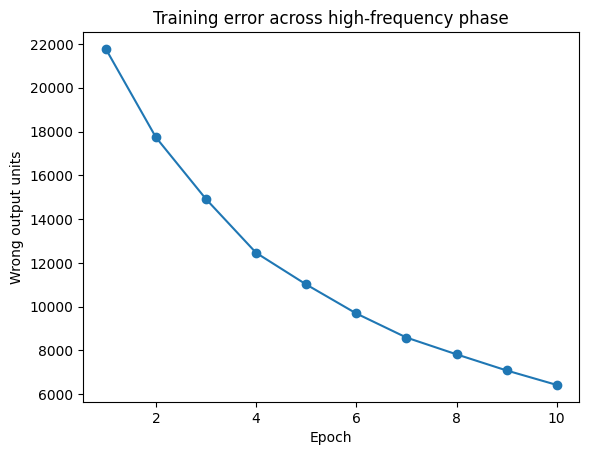

In [57]:
# Do the visualization on looking at training errors for
# 10-high frequency verbs

plt.plot(range(1, len(errors) + 1), errors, marker = "o")
plt.xlabel("Epoch")
plt.ylabel("Wrong output units")
plt.title("Training error across high-frequency phase")
plt.show()

Now, we need to track overregularization for ONE verb during high + medium training.

For example:

go -> went vs. goed

In [58]:
# Choose one irregular verb to track

example_word = "go"

# Get the row for that verb

data_eval = all_forms2.reset_index(drop = True)

example_i = data_eval.index[data_eval["word"] == example_word][0]

example_row = data_eval.loc[example_i]

print("Verb:", example_row["word"])

print("Correct past:", example_row["simple_past"])

Verb: go
Correct past: went


In [59]:
# Function to create regularized spelling

def regularized_past(word):
  if word.endswith("e"):
    return word + "d"
  elif word.endswith("y") and len(word) > 1 and word[-2] not in "aeiou":
    return word[:-1] + "ied"
  else:
    return word + "ed"

# Create overregularized spelling

overregularized_word = regularized_past(example_row["word"])

# Simple phonological approximation:
# root_rum + "d"
# Example: go = g0, so goed = gOd

overregularized_rum = example_row["root_rum"] + "d"

print("Overregularized past:", overregularized_word)

print("Correct past Rumelhart form:", example_row["past_rum"])

print("Overregularized Rumelhart form:", overregularized_rum)


Overregularized past: goed
Correct past Rumelhart form: went
Overregularized Rumelhart form: gOd


In [60]:
# Input vector for the root verb

x_example = x_combine[example_i]

# Correct target vector: went

correct_vector = y_combine[example_i]

# Overregularized target vector: goed

overregularized_vector = np.array(
    wickelfeature_vector(overregularized_rum, inventory)
)

# Store training error and overregularization information

errors_overreg = []

distance_correct_history = []

distance_overreg_history = []

choice_history = []

epoch_history = []

Now, we need to train the high + medium for 20 epochs and track this one verb.

In [61]:
for epoch in range(20):
  total_wrong = 0
  for x, target in zip(x_combine, y_combine):
    output_vector, probs = predict(
        x, w, theta,
        T = 200,
        stochastic = True
    )
    wrong = np.sum(output_vector != target)
    total_wrong += wrong
    w, theta = perceptron(
        x, target, output_vector,
        w, theta,
        eta = 1
    )
  errors_overreg.append(total_wrong)

  # After each epoch, test the example verb

  pred_example, probs_example = predict(
      x_example, w, theta,
      T = 200,
      stochastic = False
  )

  # Compare prediction to correct irregular form and overregularized
  # form

  dist_correct = np.sum(pred_example != correct_vector)
  dist_overreg = np.sum(pred_example != overregularized_vector)

  distance_correct_history.append(dist_correct)
  distance_overreg_history.append(dist_overreg)
  epoch_history.append(epoch + 1)

  # Decide which one the prediction is closer to

  if dist_overreg < dist_correct:
    choice = overregularized_word
  else:
    choice = example_row["simple_past"]
  choice_history.append(choice)

  print(
      f"Epoch {epoch + 1}: wrong units = {total_wrong}, "
      f"distance to {example_row['simple_past']} = {dist_correct}, "
      f"distance to {overregularized_word} = {dist_overreg}, "
      f"closer to = {choice}"
  )

Epoch 1: wrong units = 277551, distance to went = 86, distance to goed = 156, closer to = went
Epoch 2: wrong units = 162574, distance to went = 127, distance to goed = 115, closer to = goed
Epoch 3: wrong units = 124256, distance to went = 139, distance to goed = 103, closer to = goed
Epoch 4: wrong units = 100928, distance to went = 147, distance to goed = 95, closer to = goed
Epoch 5: wrong units = 86366, distance to went = 150, distance to goed = 92, closer to = goed
Epoch 6: wrong units = 74957, distance to went = 151, distance to goed = 91, closer to = goed
Epoch 7: wrong units = 67263, distance to went = 147, distance to goed = 95, closer to = goed
Epoch 8: wrong units = 60212, distance to went = 146, distance to goed = 96, closer to = goed
Epoch 9: wrong units = 55082, distance to went = 147, distance to goed = 95, closer to = goed
Epoch 10: wrong units = 50607, distance to went = 146, distance to goed = 96, closer to = goed
Epoch 11: wrong units = 46822, distance to went = 144

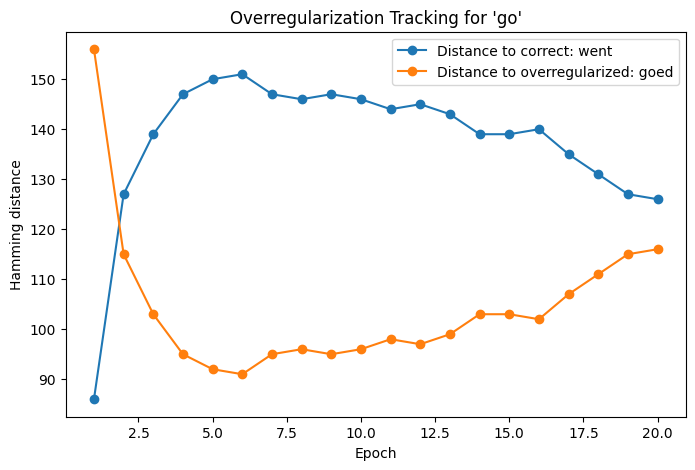

In [62]:
plt.figure(figsize = (8, 5))

plt.plot(
    epoch_history,
    distance_correct_history,
    marker = "o",
    label = f"Distance to correct: {example_row['simple_past']}"
)

plt.plot(
    epoch_history,
    distance_overreg_history,
    marker = "o",
    label = f"Distance to overregularized: {overregularized_word}"
)

plt.xlabel("Epoch")
plt.ylabel("Hamming distance")
plt.title(f"Overregularization Tracking for '{example_word}'")
plt.legend()
plt.show()

In [63]:
overreg_example_results = pd.DataFrame({
    "epoch": epoch_history,
    "word": example_word,
    "correct_past": example_row["simple_past"],
    "overregularized_past": overregularized_word,
    "distance_to_correct": distance_correct_history,
    "distance_to_overregularized": distance_overreg_history,
    "closer_to": choice_history
})

print(overreg_example_results)

    epoch word correct_past overregularized_past  distance_to_correct  \
0       1   go         went                 goed                   86   
1       2   go         went                 goed                  127   
2       3   go         went                 goed                  139   
3       4   go         went                 goed                  147   
4       5   go         went                 goed                  150   
5       6   go         went                 goed                  151   
6       7   go         went                 goed                  147   
7       8   go         went                 goed                  146   
8       9   go         went                 goed                  147   
9      10   go         went                 goed                  146   
10     11   go         went                 goed                  144   
11     12   go         went                 goed                  145   
12     13   go         went                 goed   

In [64]:
if dist_overreg < dist_correct:
  choice = overregularized_word
else:
  choice = example_row["simple_past"]

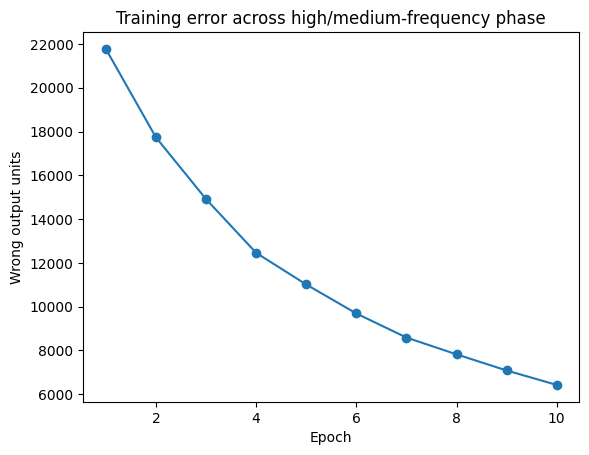

In [65]:
plt.plot(range(1, len(errors) + 1), errors, marker = "o")
plt.xlabel("Epoch")
plt.ylabel("Wrong output units")
plt.title("Training error across high/medium-frequency phase")
plt.show()

In [66]:
# Train the combined high and medium frequency together

errors_combined = []

for epoch in range (120):
  total_wrong = 0
  for x, target in zip(x_combine, y_combine):
    output_vector, probs = predict(x, w, theta, T = 200, stochastic = True)
    wrong = np.sum(output_vector != target)
    total_wrong += wrong
    w, theta = perceptron(x, target, output_vector, w, theta, eta = 1)
  errors.append(total_wrong)
  print(f"Epoch {epoch + 1}: wrong output units = {total_wrong}")

Epoch 1: wrong output units = 28045
Epoch 2: wrong output units = 27215
Epoch 3: wrong output units = 26099
Epoch 4: wrong output units = 25376
Epoch 5: wrong output units = 24142
Epoch 6: wrong output units = 23226
Epoch 7: wrong output units = 22755
Epoch 8: wrong output units = 22153
Epoch 9: wrong output units = 21376
Epoch 10: wrong output units = 20895
Epoch 11: wrong output units = 20189
Epoch 12: wrong output units = 19766
Epoch 13: wrong output units = 19195
Epoch 14: wrong output units = 18725
Epoch 15: wrong output units = 18340
Epoch 16: wrong output units = 17972
Epoch 17: wrong output units = 17443
Epoch 18: wrong output units = 17162
Epoch 19: wrong output units = 16657
Epoch 20: wrong output units = 16274
Epoch 21: wrong output units = 15999
Epoch 22: wrong output units = 15749
Epoch 23: wrong output units = 15257
Epoch 24: wrong output units = 14892
Epoch 25: wrong output units = 14732
Epoch 26: wrong output units = 14577
Epoch 27: wrong output units = 14295
Epoch 28: 

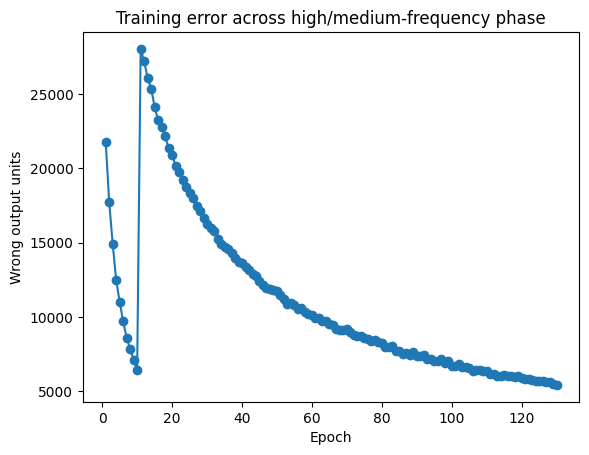

In [67]:
# Visualization on looking at training errors

plt.plot(range(1, len(errors) + 1), errors, marker = "o")
plt.xlabel("Epoch")
plt.ylabel("Wrong output units")
plt.title("Training error across high/medium-frequency phase")
plt.show()

This graph shows that the error at the first 10 epochs were the 10-high frequency verbs. Because they learned only the 10 high frequency verbs at first, it shows that the training error is decreasing. Then, after the 10 epochs, it suddenly increases sharply, which we can assume that it's because we added the 406 medium verbs. 4 verbs were dropped out because CMU did not have the pronounciation for those verbs. After it sharply increased, it gradually started to decrease as the learning rule of the perceptron updated the weights and the model learned the high and medium training set.

Now we need to check whether the output unit actually gor the right past tense verb.

In [68]:
#comparing few binary vectors first if they match

def compare_binary(data, x, y, w, theta, T = 200):
  results = []
  data_eval = data.reset_index(drop = True)
  for i, row in data_eval.iterrows():
    x_i = x[i]
    target = y[i]
    pred, probs = predict(x_i, w, theta, T = T, stochastic = False)
    wrong = np.sum(pred != target)
    correct = np.sum(pred == target)
    exact = np.array_equal(pred, target)
    predicted = pred.sum()
    target_active = target.sum()

    results.append({
        "word": row["word"],
        "simple_past" : row["simple_past"],
        "freq_band": row["freq_band"],
        "verb_class": row["verb_class"],
        "wrong" : wrong,
        "correct" : correct,
        "exact" : exact,
        "predicted" : predicted,
        "target_active" : target_active
    })
  return pd.DataFrame(results)

In [69]:
x_i = x_combine[0]

pred, probs = predict(
    x_i,
    w,
    theta,
    T=200,
    stochastic=False
)

print("Predicted active units:", pred.sum())
print("Target active units:", y_combine[0].sum())
print("Probability min:", probs.min())
print("Probability max:", probs.max())
print("First 20 probabilities:", probs[:20])

Predicted active units: 96
Target active units: 96
Probability min: 3.860052194790782e-08
Probability max: 0.9996995714112696
First 20 probabilities: [7.90777446e-05 7.52213676e-05 7.31267276e-04 2.77336947e-04
 6.92160702e-04 1.70773782e-04 8.66657211e-04 7.27622719e-04
 4.70148515e-05 1.31680544e-04 3.89600121e-04 1.56860000e-04
 4.66400193e-04 1.67544438e-03 1.47150060e-03 9.48196644e-04
 1.33670375e-04 7.53520899e-04 4.45886561e-04 4.83005208e-04]


In [70]:
w_trained = w.copy()
theta_trained = theta.copy()

binary = compare_binary(
    data = all_forms2,
    x = x_combine,
    y = y_combine,
    w = w_trained,
    theta = theta_trained,
    T = 200
)

print(binary)

        word simple_past freq_band verb_class  wrong  correct  exact  \
0       have         had      high  irregular      0     4608   True   
1        get         got      high  irregular      0     4608   True   
2         go        went      high  irregular      0     4608   True   
3       make        made      high  irregular      0     4608   True   
4       take        took      high  irregular      0     4608   True   
..       ...         ...       ...        ...    ...      ...    ...   
411   result    resulted    medium    regular      0     4608   True   
412  explore    explored    medium    regular      0     4608   True   
413   regain    regained    medium    regular      0     4608   True   
414  scratch   scratched    medium    regular      0     4608   True   
415    guard     guarded    medium    regular      0     4608   True   

     predicted  target_active  
0           96             96  
1           96             96  
2          160            160  
3      

In [71]:
print(binary["exact"].mean())
print(binary["wrong"].mean())
print(binary.sort_values("wrong", ascending = False).head(20))

0.9615384615384616
0.9759615384615384
         word simple_past freq_band verb_class  wrong  correct  exact  \
10       sink        sank    medium  irregular    129     4479  False   
80      drive       drove    medium  irregular    104     4504  False   
66      think     thought    medium  irregular     79     4529  False   
297    derive     derived    medium    regular     54     4554  False   
8        feel        felt      high  irregular     24     4584  False   
85       send        sent    medium  irregular      4     4604  False   
25       rise        rose    medium  irregular      2     4606  False   
201      chat     chatted    medium    regular      2     4606  False   
84       tear        tore    medium  irregular      1     4607  False   
31      bring     brought    medium  irregular      1     4607  False   
77       hold        held    medium  irregular      1     4607  False   
292      tend      tended    medium    regular      1     4607  False   
408      fold

DECODING

In [72]:
# Find which known past-tense vector is closes to the model's
# predicted output vector

def distance(vec1, vec2):
  return np.sum(vec1 != vec2)

def decoding(pred_vector, candidate_data, candidate_Y):
  distances = np.array([
      distance(pred_vector, candidate_Y[i])
      for i in range(len(candidate_Y))
  ])
  best_i = np.argmin(distances)
  return {
      "past": candidate_data.iloc[best_i]["simple_past"],
      "root": candidate_data.iloc[best_i]["word"],
      "distance": distances[best_i]
  }

In [73]:
# Decode for all high and medium verbs

def evaluating(data, x, y, w, theta, candidate_data, candidate_Y, T = 200):
  results = []
  data_eval = data.reset_index(drop = True)
  candidate_data = candidate_data.reset_index(drop = True)
  for i, row in data_eval.iterrows():
    x_i = x[i]
    pred_vector, probs = predict(
        x_i, w, theta,
        T = T,
        stochastic = False
    )
    decoded = decoding(
        pred_vector, candidate_data = candidate_data,
        candidate_Y = candidate_Y
    )

    correct = decoded["past"] == row["simple_past"]
    results.append({
        "word" : row["word"],
        "target_past" : row["simple_past"],
        "decoded_past" : decoded["past"],
        "decoded_root" : decoded["root"],
        "freq_band" : row["freq_band"],
        "verb_class" : row["verb_class"],
        "correct" : correct,
        "distance" : decoded["distance"]
    })
  return pd.DataFrame(results)

training_decode = evaluating(
    data = all_forms2,
    x = x_combine,
    y = y_combine,
    w = w,
    theta = theta,
    candidate_data = all_forms2,
    candidate_Y = y_combine,
    T = 200
)

print(training_decode.head(20))

        word target_past decoded_past decoded_root freq_band verb_class  \
0       have         had          had         have      high  irregular   
1        get         got          got          get      high  irregular   
2         go        went         went           go      high  irregular   
3       make        made         made         make      high  irregular   
4       take        took         took         take      high  irregular   
5       come        came         came         come      high  irregular   
6       give        gave         gave         give      high  irregular   
7       look      looked       looked         look      high    regular   
8       feel        felt         felt         feel      high  irregular   
9       live       lived        lived         live      high    regular   
10      sink        sank       sought         seek    medium  irregular   
11      hurt        hurt         hurt         hurt    medium  irregular   
12      hang        hung 

In [74]:
print(training_decode["correct"].mean())
print(training_decode.groupby("verb_class").agg(n = ("word", "count"),
                                                accuracy = ("correct", "mean"),
                                                avg = ("distance", "mean")))
print(training_decode[training_decode["correct"] == False].sort_values("distance", ascending = False).head(20))


0.9855769230769231
              n  accuracy       avg
verb_class                         
irregular    84  0.952381  2.940476
regular     332  0.993976  0.177711
        word target_past decoded_past decoded_root freq_band verb_class  \
10      sink        sank       sought         seek    medium  irregular   
66     think     thought       sought         seek    medium  irregular   
80     drive       drove      derived       derive    medium  irregular   
45     fight      fought       sought         seek    medium  irregular   
109  arrange    arranged       ranged        range    medium    regular   
318  descend   descended     defended       defend    medium    regular   

     correct  distance  
10     False        79  
66     False        79  
80     False        54  
45     False         0  
109    False         0  
318    False         0  


Now we need to do the low-frequency test set.

In [75]:
# Do the same steps for cmu pronouncations for low-frequency verbs

low["root_cmu"] = low["word"].apply(cmu)
low["past_cmu"] = low["simple_past"].apply(cmu)

low["root_rum"] = low["root_cmu"].apply(rumelhart)
low["past_rum"] = low["past_cmu"].apply(rumelhart)

low = low.dropna(subset = ["root_cmu", "past_cmu", "root_rum", "past_rum"]).copy()
low = low.reset_index(drop = True)
print(low.shape)

(86, 9)


In [76]:
# Create wickelphones, wickelfeatures, and vectors for low frequency verbs

low["root_wickel"] = low["root_rum"].apply(wickelphones)
low["past_wickel"] = low["past_rum"].apply(wickelphones)

low["root_features"] = low["root_rum"].apply(wickelfeatures)
low["past_features"] = low["past_rum"].apply(wickelfeatures)

low["root_vector"] = low["root_rum"].apply(
    lambda x: wickelfeature_vector(x, inventory))

low["past_vector"] = low["root_rum"].apply(
    lambda x: wickelfeature_vector(x, inventory))

low["root_active"] = low["root_vector"].apply(sum)
low["past_active"] = low["past_vector"].apply(sum)

In [77]:
x_low = np.array(low["root_vector"].tolist())
y_low = np.array(low["past_vector"].tolist())

print(x_low.shape)
print(y_low.shape)
print(w.shape)
print(theta.shape)

(86, 4608)
(86, 4608)
(4608, 4608)
(4608,)


In [78]:
low_binary = compare_binary(
    data = low,
    x = x_low,
    y = y_low,
    w = w,
    theta = theta,
    T = 200
)

print(low_binary.head(20))

         word simple_past freq_band verb_class  wrong  correct  exact  \
0         put         put       low  irregular     89     4519  False   
1         say        said       low  irregular     41     4567  False   
2    overcome    overcame       low  irregular    254     4354  False   
3       sweep       swept       low  irregular    126     4482  False   
4         win         won       low  irregular     59     4549  False   
5        wake        woke       low  irregular     51     4557  False   
6       throw       threw       low  irregular     91     4517  False   
7       light         lit       low  irregular    156     4452  False   
8        knit        knit       low  irregular    104     4504  False   
9      spread      spread       low  irregular     37     4571  False   
10      arise       arose       low  irregular     48     4560  False   
11       quit        quit       low  irregular     97     4511  False   
12      shoot        shot       low  irregular     

In [79]:
low_decode = evaluating(
    data = low,
    x = x_low,
    y = y_low,
    w = w,
    theta = theta,
    candidate_data = low,
    candidate_Y = y_low,
    T=200
)

print(low_decode.head(20))

         word target_past decoded_past decoded_root freq_band verb_class  \
0         put         put          put          put       low  irregular   
1         say        said         said          say       low  irregular   
2    overcome    overcame         said          say       low  irregular   
3       sweep       swept        swept        sweep       low  irregular   
4         win         won          won          win       low  irregular   
5        wake        woke         woke         wake       low  irregular   
6       throw       threw        threw        throw       low  irregular   
7       light         lit          lit        light       low  irregular   
8        knit        knit         knit         knit       low  irregular   
9      spread      spread       spread       spread       low  irregular   
10      arise       arose        arose        arise       low  irregular   
11       quit        quit         quit         quit       low  irregular   
12      shoo

In [80]:
print(low_decode["correct"].mean())
print(low_decode.groupby("verb_class").agg(n = ("word", "count"),
                                                accuracy = ("correct", "mean"),
                                                avg = ("distance", "mean")))
print(low_decode[low_decode["correct"] == False].sort_values("distance", ascending = False).head(20))

0.8837209302325582
             n  accuracy         avg
verb_class                          
irregular   14  0.928571   98.714286
regular     72  0.875000  155.166667
           word   target_past decoded_past decoded_root freq_band verb_class  \
43  communicate  communicated         knit         knit       low    regular   
22     reassure     reassured         said          say       low    regular   
2      overcome      overcame         said          say       low  irregular   
64       submit     submitted         knit         knit       low    regular   
34     flourish    flourished         said          say       low    regular   
36      dislike      disliked         knit         knit       low    regular   
30     overlook    overlooked        opted          opt       low    regular   
76        cover       covered     governed       govern       low    regular   
54         ruin        ruined         said          say       low    regular   
26        shape        shaped    